# Gate-Sequence Optimization: A Tutorial

`gkp_optimal_control.gate_optimization` optimizes the *parameters of a fixed-depth circuit* rather than a time-domain control pulse. The gates are treated as ideal unitaries: no Kerr, no finite pulse duration, no dispersive phase accumulation. The result is therefore an *upper* bound on what a real circuit of that depth achieves, and a useful decoupling of circuit expressivity from pulse-level imperfection.

This notebook walks through the module end to end: displacement construction, a first small optimization, the anatomy of a result, the two gate sets, convergence diagnostics, layer-by-layer Wigner functions, warm starts, and finally optimizing a *gate* on the logical subspace rather than a single state.

## The two ansaetze

**ECD + qubit rotations** (Eickbusch *et al.*, *Nat. Phys.* **18**, 1464 (2022)) uses a transmon ancilla dispersively coupled to the cavity:

$$U = R(\theta_{N+1}, \phi_{N+1}) \prod_{i=N}^{1} \mathrm{ECD}(\beta_i)\, R(\theta_i, \phi_i),$$

$$\mathrm{ECD}(\beta) = D(\beta/2)\,\ket{e}\bra{g} + D(-\beta/2)\,\ket{g}\bra{e}, \qquad R(\theta,\phi) = \exp\!\left[-\tfrac{i\theta}{2}\left(\sigma_x\cos\phi + \sigma_y\sin\phi\right)\right].$$

The qubit is never represented explicitly. Since both ECD and $R$ are $2\times 2$ block operators on the qubit index, the state is carried as a *pair* of cavity kets $(\psi_g, \psi_e)$, which halves the memory and the cost of every displacement relative to a $2 n_{\text{fock}}$ joint space. With $N$ ECDs there are $N+1$ rotations and $4N + 2$ real parameters.

**SNAP + displacements** (Heeres *et al.*, *PRL* **115**, 137002 (2015)) acts on the cavity alone:

$$U = D(\alpha_{N+1}) \prod_{i=1}^{N} S(\vec\theta_i)\, D(\alpha_i), \qquad S(\vec\theta) = \sum_n e^{i\theta_n}\ket{n}\bra{n},$$

with $N$ SNAPs, $N+1$ displacements, and $N n_{\text{snap}} + 2(N+1)$ parameters.

In both cases `n_gates` counts ECDs or SNAPs — not the total gate count.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import jax

jax.config.update("jax_enable_x64", True)  # before any array is created

import jax.numpy as jnp
import jaxquantum as jqt
import matplotlib.pyplot as plt

from gkp_optimal_control.gate_optimization import (
    GateBounds,
    OptimizerConfig,
    make_displacement,
    optimize_gate_sequence,
    sequence_history,
)
from gkp_optimal_control.plotting import (
    plot_photon_number,
    plot_wigner,
    set_plot_style,
)
from gkp_optimal_control.states import cat_states, gkp_states
from gkp_optimal_control.utils import to_ket, to_qarray

set_plot_style()

The `jax.config.update` call has to come *before* any array is created, which is why it sits between the two imports above rather than at the bottom of the cell. In FP32 the fidelity plateaus around $1 - 10^{-6}$ and the optimizer will chase numerical noise past that; `optimize_gate_sequence` emits a `RuntimeWarning` if x64 is off.

Everything below stays in `jax.numpy`. Matplotlib accepts JAX arrays directly (it calls `__array__` on them), so no host conversion is needed for plotting; the only `float()` casts are where a Python scalar is wanted for an f-string.

## A note on state types

This project deliberately keeps two representations of a state. The differentiable modules — `grape`, `hamiltonians`, `gate_optimization` — work in raw `jnp` arrays, because `Qarray` does not survive `vmap`, `lax.scan`, and `value_and_grad` cleanly. The physics-object modules — `brachistochrone`, `plotting`, `utils` — work in `jaxquantum.Qarray`, because `jqt.wigner` and `jqt.sesolve` require it.

`utils` provides the two crossings, and both are idempotent, so you never need to remember which side of the line a given state came from:

- `to_qarray(state)` — raw array or `Qarray` in, `Qarray` out. Accepts a 1D ket, a column ket, or a density matrix.
- `to_ket(state)` — either in, flat normalized 1D `jnp` array out. Raises on a density matrix, which has no ket representation.

One sharp edge behind this. `Qarray.__getattr__` raises `NotImplementedError` rather than `AttributeError` for an unknown attribute, so *any* duck-typing probe crashes on a `Qarray` instead of falling through — including `hasattr(state, ...)`, and including `jnp.asarray(state)`, which reaches for `.aval` internally inside a `try/except AttributeError`. Dispatch on `isinstance(state, jqt.Qarray)` first, before touching any attribute. `to_qarray` does exactly that.

The state constructors are also not uniform: `gkp_states` normalizes with the `Qarray` method `.unit()` and returns `Qarray`s, while `cat_states` uses the function `jqt.unit(...)`, which drops the wrapper and returns a bare array. The helpers absorb the difference; the underlying fix is `return even_cat.unit(), odd_cat.unit()` in `states.py`.

## Displacement operators

Every gate in both ansaetze is built from $D(\alpha)$, so the way $D$ is constructed sets both the accuracy and the speed of the whole optimization. `make_displacement` returns a jittable `alpha -> D(alpha)` closure with two available methods:

| `disp_method` | Construction | Notes |
|---|---|---|
| `"expm"` (default) | $\exp(\alpha a^\dagger - \alpha^* a)$ of the truncated generator | exactly unitary; gradients flow through an `expm` Frechet derivative |
| `"quadrature"` | BCH form $e^{-i x_0 p_0} e^{i\sqrt{2} p_0 \hat x} e^{-i\sqrt{2} x_0 \hat p}$ with $\hat x, \hat p$ eigendecomposed once | exactly unitary, same accuracy, roughly 4x faster; gradients flow through a diagonal exponential |

A third option — assembling $\bra{m} D(\alpha) \ket{n}$ from the closed-form matrix elements — is deliberately *not* offered. Those are the exact infinite-dimensional elements restricted to a truncated block, so the matrix is not unitary ($\lVert D^\dagger D - I \rVert \approx 0.5$ at $n_{\text{fock}} = 40$), norm is not conserved, and an optimizer will happily exploit that to report fidelities it never achieved. Verify unitarity for yourself before trusting either method:

In [2]:
n_fock = 80
alpha_test = 1.0 + 0.5j

for method in ("expm", "quadrature"):
    d_op = make_displacement(n_fock, method)(alpha_test)
    unitarity_err = jnp.abs(d_op.conj().T @ d_op - jnp.eye(n_fock)).max()
    print(f"{method:>11}: ||D^dag D - I||_max = {float(unitarity_err):.2e}")

d_expm = make_displacement(n_fock, "expm")(alpha_test)
d_quad = make_displacement(n_fock, "quadrature")(alpha_test)
print(f"\nexpm vs quadrature: {float(jnp.abs(d_expm - d_quad).max()):.2e}")

       expm: ||D^dag D - I||_max = 1.55e-15
 quadrature: ||D^dag D - I||_max = 4.00e-15

expm vs quadrature: 5.80e-01


## Target states

Any ket the module can coerce works as an initial or target state: a `jaxquantum.Qarray`, a raw `(n_fock,)` or `(n_fock, 1)` array, a batched `(K, n_fock)` array, or a list of those. Everything is normalized internally, and `n_fock` is inferred if you do not pass it.

We set up a few targets of increasing difficulty: a Fock state, an even cat, and the finite-energy GKP logical $\ket{0_L}$.

In [18]:
gkp_delta = 0.3
gkp_cutoff = 10
gkp_alpha = jnp.sqrt(jnp.pi / 2)
gkp_beta = 1j * jnp.sqrt(jnp.pi / 2)

vac = jqt.basis(n_fock, 0)
fock_3 = jqt.basis(n_fock, 3)
even_cat, _ = cat_states(n_fock, 2.0)
gkp_0, gkp_1 = gkp_states(n_fock, gkp_alpha, gkp_beta, gkp_delta, gkp_cutoff)

ns = jnp.arange(n_fock)
for label, state in [("|3>", fock_3), ("even cat", even_cat), ("|0_L>", gkp_0)]:
    probs = jnp.abs(to_ket(state)) ** 2
    n_bar = jnp.sum(ns * probs)
    tail = jnp.sum(probs[-8:])
    print(f"{label:>9}:  n_bar = {float(n_bar):6.2f}   top-8 Fock population = {float(tail):.2e}")

      |3>:  n_bar =   3.00   top-8 Fock population = 0.00e+00
 even cat:  n_bar =   4.00   top-8 Fock population = 1.34e-62
    |0_L>:  n_bar =   5.83   top-8 Fock population = 9.03e-06


The top-of-truncation population matters twice over. A target with support at the truncation boundary is not representable, and — more subtly — *intermediate* states in the circuit are displaced further out than either endpoint, so a target that fits comfortably can still drive the optimizer into the boundary mid-circuit. That is what the leakage penalty below is for.

## A first optimization

The minimal call is `optimize_gate_sequence(gate_set, n_gates, psi_init, psi_targ)`. Everything after that is keyword-only. Here: prepare $\ket{3}$ from vacuum with four SNAP gates, keeping the run small so it finishes in seconds.

`n_snap=12` optimizes only the first twelve Fock phases per SNAP gate and pins the rest to zero — the physically honest choice, since the selective qubit pulses that implement SNAP only resolve low photon numbers. Leaving it `None` would optimize all `n_fock` phases and give the ansatz far more freedom than hardware has.

In [4]:
res_snap = optimize_gate_sequence(
    "snap+displacements",
    4,
    vac,
    fock_3,
    n_snap=12,
    loss_type="log_infidelity",
    optimizer=OptimizerConfig(n_seeds=6, n_adam_iters=600, seed=1),
)

gate set : snap   depth : 4   n_fock : 80
params   : 58   state pairs : 1   reduction : mean
loss     : log_infidelity   disp : expm   seeds : 6   n_snap : 12
--------------------------------------------------------------
Adam (600 iters x 6 seeds) in 93.4s
  seed fidelities: best 0.999994, median 0.999989, worst 0.999701
  best seed: 5
L-BFGS-B polish: 500 iters in 7.5s  ->  F = 0.999997
--------------------------------------------------------------
Final fidelity : 0.999997   (infidelity 2.595e-06)
Leakage        : 2.713e-33  (top 5 Fock levels)
Peak |disp|    : 1.658
Total time     : 102.1s


## Anatomy of a `GateOptResult`

`verbose=True` (the default) prints a running report; `summary()` reprints the headline numbers, and the object carries everything needed to reproduce or inspect the solution.

| Attribute | Contents |
|---|---|
| `fidelity`, `loss`, `leakage` | achieved $F$, final objective value (penalties included), population in the top `n_leak` levels |
| `params` | labelled dict — `thetas`/`phis`/`betas` for ECD, `snap_phases`/`alphas` for SNAP, plus `disp_magnitudes` and `per_pair_fidelity` |
| `flat_params` | the raw parameter vector, for warm starts |
| `final_states` | `(K, n_fock)` for SNAP, `(K, 2, n_fock)` for ECD (qubit block index second-to-last) |
| `per_seed_fidelity`, `best_seed` | multi-start spread and which seed won |
| `adam_history` | `(n_seeds, n_adam_iters)` loss trace |
| `polish_info` | L-BFGS-B iterations, success flag, fidelity before/after |
| `config` | every option used, which is what `sequence_history` reads back |

The array-valued fields come back as host `numpy` arrays, since they cross out of JAX at the end of the run — wrap them in `jnp.asarray` to keep working on device, as below. `final_qarray()` is the shortcut to a plottable state; for ECD it returns the $\ket{g}$ block renormalized.

In [5]:
print(res_snap.summary())
print()
print("params  :", {k: jnp.shape(v) for k, v in res_snap.params.items()})
print("polish  :", res_snap.polish_info)

alphas = jnp.asarray(res_snap.params["alphas"])
print("alphas  :", [f"{a:.3f}" for a in alphas])

gate set        : snap
n_gates         : 4
n_params        : 58
fidelity        : 0.999997
infidelity      : 2.595e-06
loss            : -1.286189e+01
leakage         : 2.713e-33
best seed       : 5 of 6
seed F spread   : 0.9997 .. 1.0000

params  : {'snap_phases': (4, 12), 'alphas': (5,), 'disp_magnitudes': (5,), 'per_pair_fidelity': (1,)}
polish  : {'nit': 500, 'success': False, 'message': 'STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT', 'fidelity_before': 0.9999943766073194, 'fidelity_after': 0.9999974049232346, 'time': 7.539467096328735}
alphas  : ['-0.527-0.132j', '0.313-0.785j', '-0.985+0.473j', '-0.064+1.656j', '-0.288+0.098j']


## The configuration objects

Three groups of keyword arguments control a run: the ansatz, the objective, and the optimizer.

**Ansatz** — `n_snap` (SNAP only, phases per gate); `echoed` (`True` for the echoed conditional displacement, `False` for the bare $D(\beta/2)\ket{g}\bra{g} + D(-\beta/2)\ket{e}\bra{e}$); `qubit_target` (`"ground"` scores $|\braket{\psi_t | \psi_g}|^2$ and so demands the qubit come back to $\ket{g}$ disentangled — the standard choice; `"traced"` scores $\bra{\psi_t}\rho_{\text{cav}}\ket{\psi_t}$ and lets the qubit end anywhere, meaningful only if you genuinely discard it); `disp_method` as discussed above.

**Objective** — `loss_type` is `"infidelity"`, `"neg_fidelity"`, or `"log_infidelity"`. Prefer the last once you are pushing past $F = 0.99$, where $1 - F$ is nearly flat and gradients vanish. `batch_reduction` matters only for multiple state pairs (see the final section). `GateBounds` supplies two soft, differentiable penalties:

- `max_disp` / `max_disp_weight` — penalizes $\max(|d| - d_{\max}, 0)^2$ on $|\beta_i|$ or $|\alpha_i|$. This is a penalty rather than a hard box bound on purpose: box bounds on $\mathrm{Re}\,\beta$ and $\mathrm{Im}\,\beta$ would constrain a square rather than a disk, and Adam would not respect them anyway.
- `n_leak` / `leakage_weight` — population in the top `n_leak` Fock levels, accumulated after *every* displacement in the circuit rather than only at the end.

**Optimizer** — `OptimizerConfig` runs `n_seeds` random initializations in parallel under `vmap`, each for `n_adam_iters` Adam steps on a cosine schedule (`peak_lr`, `warmup_frac`, `final_lr_frac`), then polishes the best seed with L-BFGS-B unless `polish=False`. The multi-start is not decoration: this landscape is far more non-convex than GRAPE's, and single-start descent routinely stalls in poor minima. Watch the seed spread in the printout to see how badly.

In [6]:
bounds = GateBounds(max_disp=4.0, n_leak=8)
optimizer = OptimizerConfig(n_seeds=16, n_adam_iters=2000, peak_lr=0.03, seed=0)

## ECD preparation of the GKP $\ket{0_L}$

Now the real workload: twelve ECD layers with the config above — 16 seeds, 2000 Adam iterations each, a displacement cap at $|\beta| = 4$, and a leakage penalty over the top eight Fock levels. `disp_method="quadrature"` is worth using here: the cost per gate is dominated by building $D(\alpha)$, which is $O(n_{\text{fock}}^3)$, and it is applied `n_gates` times per seed per iteration.

Expect minutes rather than seconds. For calibration, a run of 5 ECD layers at `n_fock=100` with the same 16 x 2000 budget took about 90 s on this codebase; cost scales roughly linearly in depth and in seed count.

In [19]:
res_ecd = optimize_gate_sequence(
    "ecd",
    16,
    vac,
    gkp_0,
    disp_method="quadrature",
    loss_type="log_infidelity",
    bounds=bounds,
    optimizer=optimizer,
)

gate set : ecd   depth : 16   n_fock : 80
params   : 66   state pairs : 1   reduction : mean
loss     : log_infidelity   disp : quadrature   seeds : 16
--------------------------------------------------------------
Adam (2000 iters x 16 seeds) in 207.1s
  seed fidelities: best 0.997462, median 0.971278, worst 0.936572
  best seed: 8
L-BFGS-B polish: 500 iters in 5.0s  ->  F = 0.997490
--------------------------------------------------------------
Final fidelity : 0.997490   (infidelity 2.510e-03)
Leakage        : 5.809e-06  (top 8 Fock levels)
Peak |disp|    : 2.818
Total time     : 212.8s


## Convergence and seed spread

Two diagnostics worth looking at after every run. On the left, the Adam loss trace for each seed — note that the plotted quantity includes the leakage and displacement penalties, so it is not a pure $\log(1 - F)$. On the right, the distribution of final infidelities across seeds. A wide spread means the multi-start is doing real work and more seeds would likely help; a tight spread at high infidelity means the *ansatz* is the limitation and you should add depth instead.

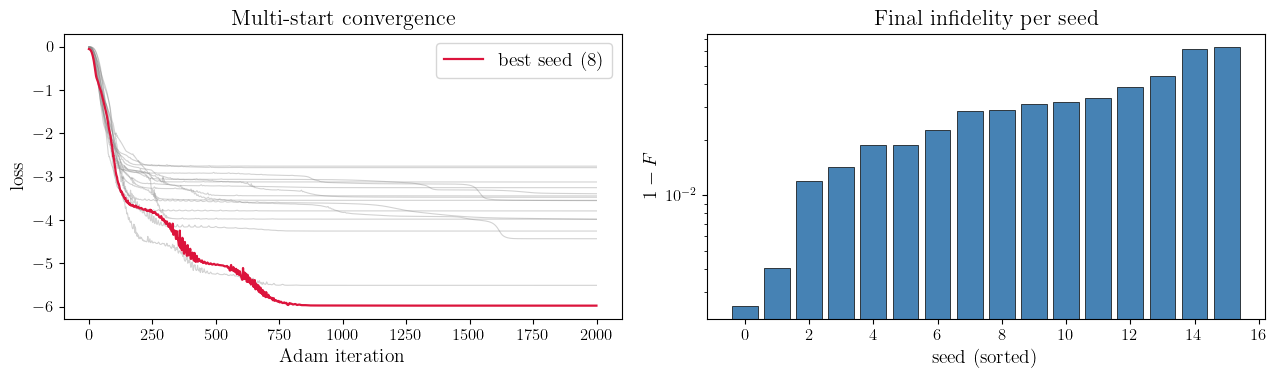

In [20]:
history = jnp.asarray(res_ecd.adam_history)
seed_fids = jnp.asarray(res_ecd.per_seed_fidelity)
iters = jnp.arange(history.shape[1])

fig, (ax_hist, ax_seeds) = plt.subplots(1, 2, figsize=(13, 4))

for k in range(history.shape[0]):
    ax_hist.plot(iters, history[k], color="gray", alpha=0.35, linewidth=0.8)
ax_hist.plot(
    iters,
    history[res_ecd.best_seed],
    color="crimson",
    linewidth=1.6,
    label=f"best seed ({res_ecd.best_seed})",
)
ax_hist.set_xlabel("Adam iteration")
ax_hist.set_ylabel("loss")
ax_hist.set_title("Multi-start convergence")
ax_hist.legend()

sorted_infid = 1 - jnp.sort(seed_fids)[::-1]
ax_seeds.bar(
    jnp.arange(sorted_infid.size),
    sorted_infid,
    color="steelblue",
    edgecolor="black",
    linewidth=0.5,
)
ax_seeds.set_yscale("log")
ax_seeds.set_xlabel("seed (sorted)")
ax_seeds.set_ylabel(r"$1 - F$")
ax_seeds.set_title("Final infidelity per seed")

fig.tight_layout()
plt.show()

## Achieved state vs. target

For the ECD set with `qubit_target="ground"`, the fidelity is $|\braket{\psi_t | \psi_g}|^2$: a high value certifies both that the cavity reached the target *and* that the qubit returned to $\ket{g}$ disentangled. `final_qarray()` hands back that $\ket{g}$ block, renormalized.

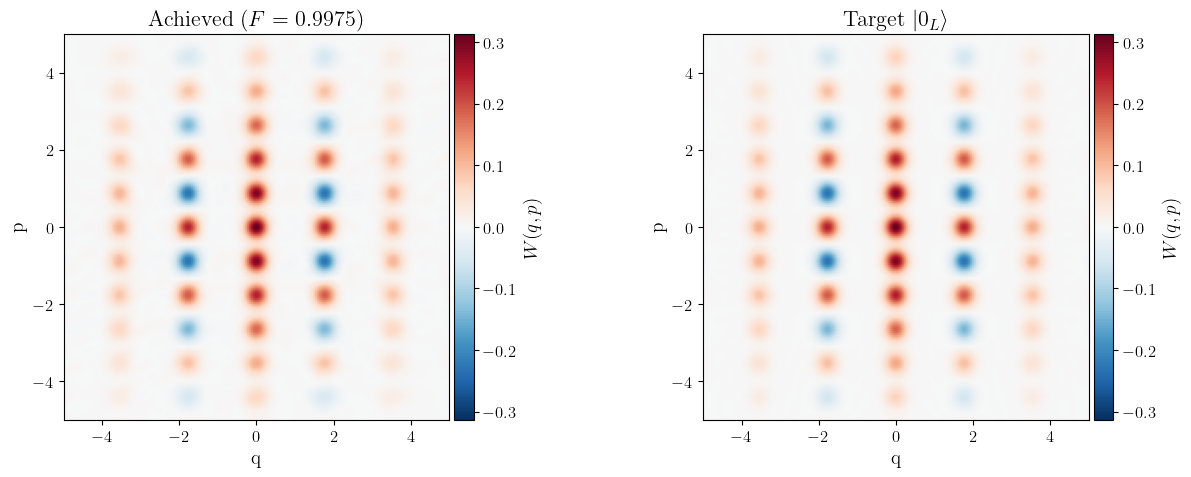

In [21]:
psi_final = res_ecd.final_qarray()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_wigner(psi_final, x_bound=5, y_bound=5, ax=axes[0],
            title=rf"Achieved ($F = {res_ecd.fidelity:.4f}$)")
plot_wigner(gkp_0, x_bound=5, y_bound=5, ax=axes[1],
            title=r"Target $\ket{0_L}$")
fig.tight_layout()
plt.show()

Photon-number distributions are the quicker check on truncation health: population piling up near $n = n_{\text{fock}}$ means the leakage penalty was too weak, `n_leak` too small, or `n_fock` simply too tight for the displacements the optimizer wants to use.

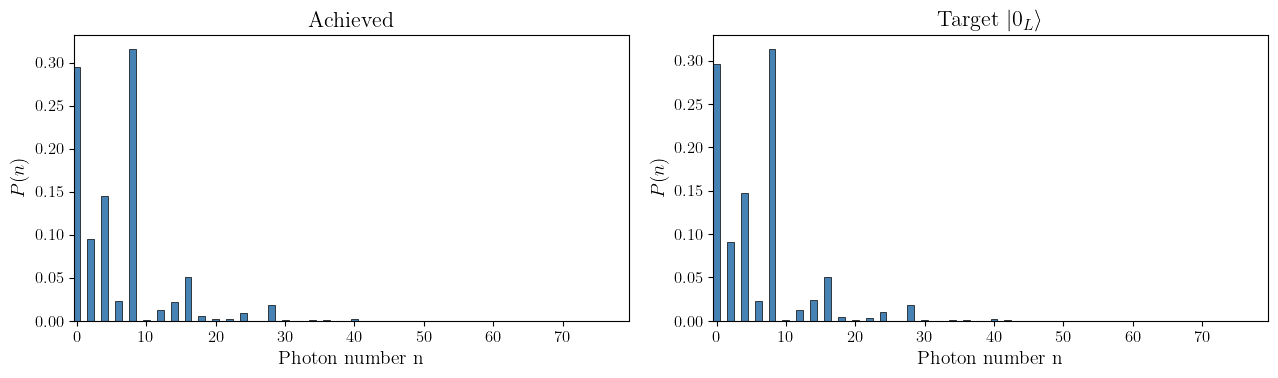

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_photon_number(psi_final, ax=axes[0], title="Achieved")
plot_photon_number(gkp_0, ax=axes[1], title=r"Target $\ket{0_L}$")
fig.tight_layout()
plt.show()

## Layer-by-layer Wigner functions

`sequence_history(result, psi_init)` re-runs the optimized circuit and returns the state after *every* gate, reading the ansatz options back out of `result.config`. The leading axis has length `2 * n_gates + 2`, laid out as

```
index 0        : input state
index 1        : after the first rotation (ECD) / first displacement (SNAP)
index 2 + 2i   : after ECD i+1 / SNAP i+1
index 3 + 2i   : after the rotation / displacement that follows it
```

so the ends of complete layers are `range(3, 2 * n_gates + 2, 2)`. The remaining axes are `(K, n_fock)` for SNAP and `(K, 2, n_fock)` for ECD, where the second-to-last axis indexes the qubit block $(\ket{g}, \ket{e})$.

That qubit axis needs care. Mid-circuit the cavity is genuinely entangled with the ancilla, so there is no cavity *ket* to plot — the honest object is the reduced density matrix $\rho_{\text{cav}} = \ket{\psi_g}\bra{\psi_g} + \ket{\psi_e}\bra{\psi_e}$. The helper below returns a `Qarray` either way, so `plot_wigner` handles both gate sets unchanged.

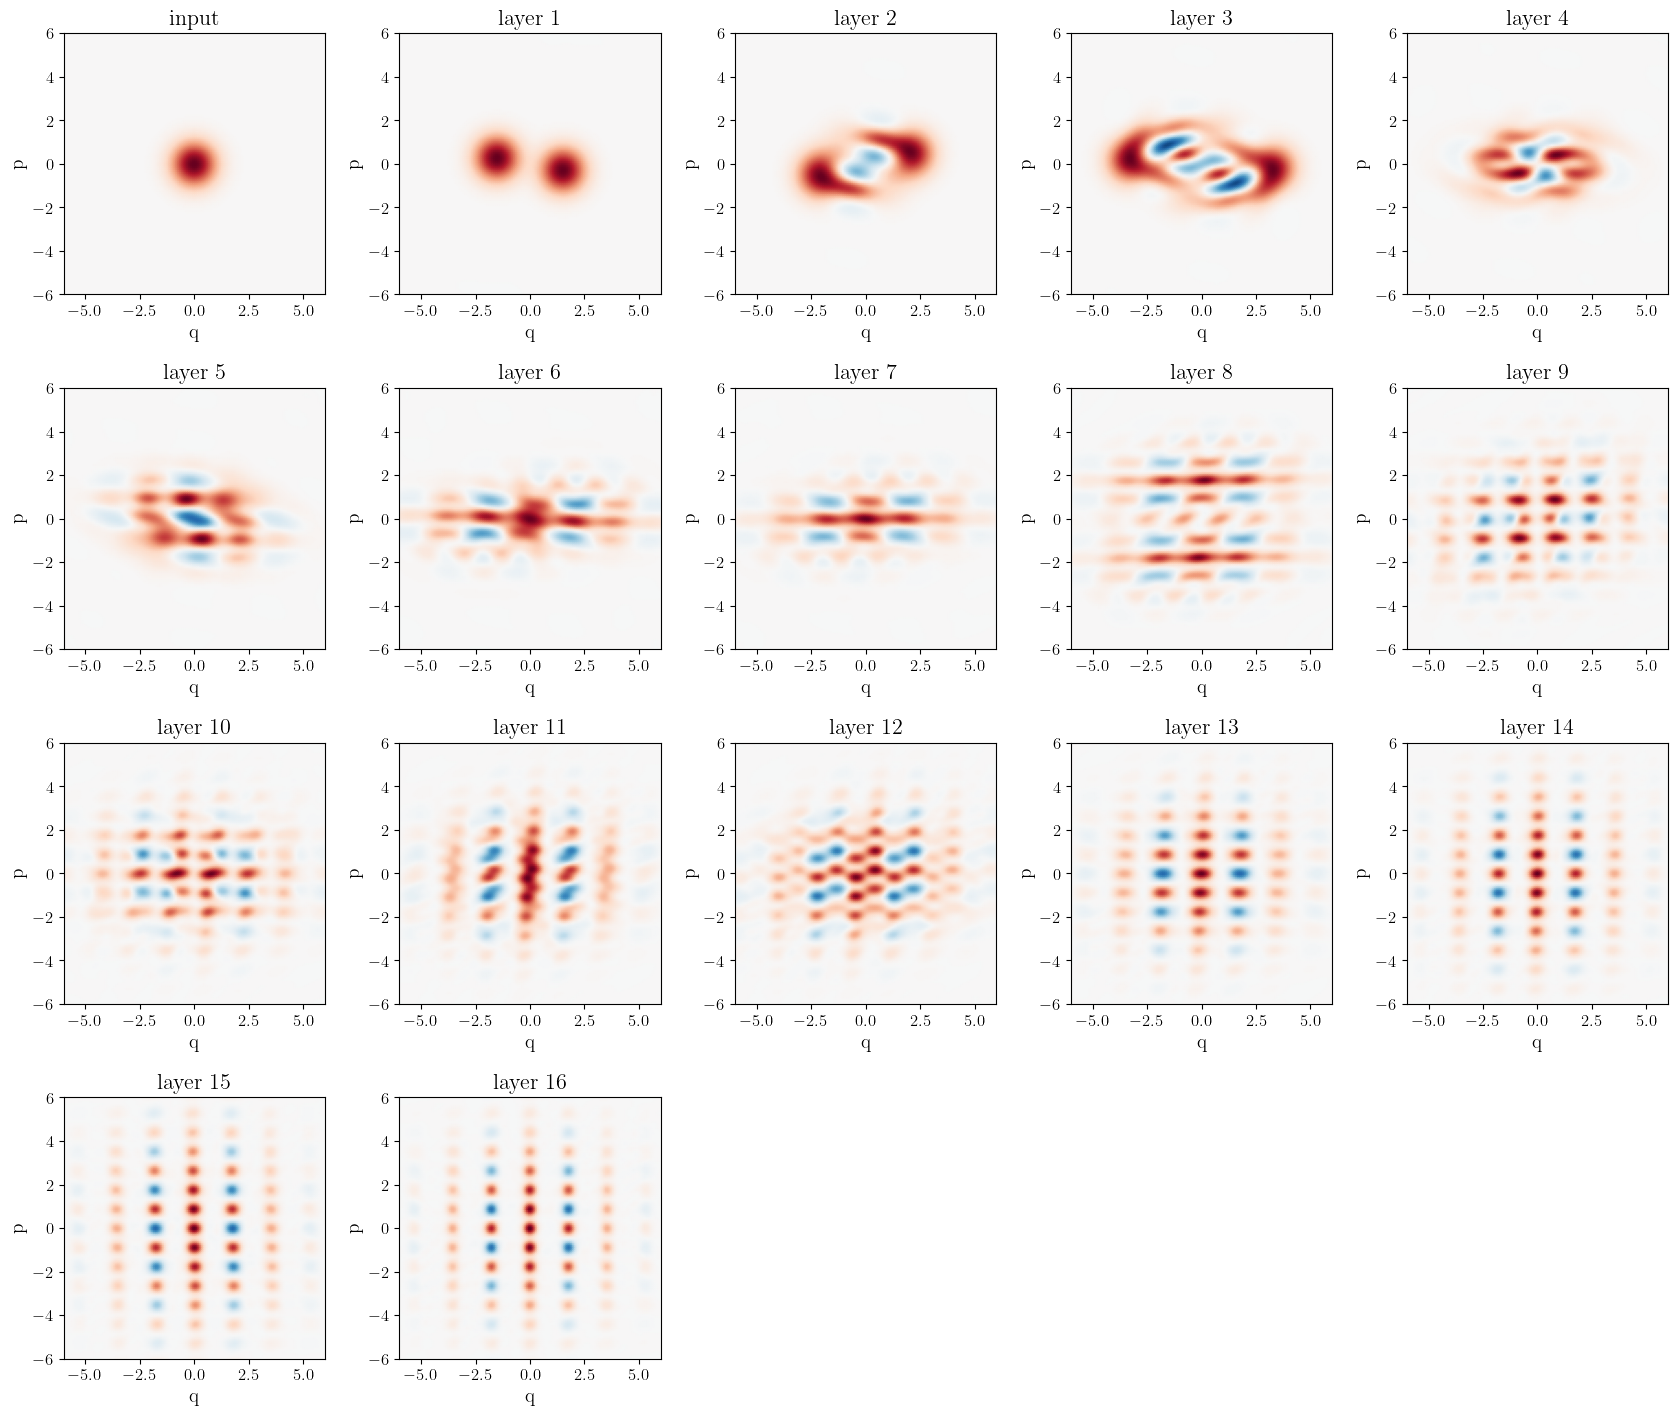

In [23]:
def frame_to_qarray(frame):
    """One frame of a sequence_history slice -> a Qarray for plot_wigner.

    ECD frames are (2, n_fock) qubit blocks, which to_qarray rejects as
    ambiguous, so trace the qubit down to a cavity density matrix first.
    SNAP frames are plain (n_fock,) kets and pass straight through.
    """
    arr = jnp.asarray(frame)
    if arr.ndim == 2:  # ECD: trace out the qubit
        rho = arr.T @ arr.conj()
        return to_qarray(rho / jnp.real(jnp.trace(rho)))
    return to_qarray(arr)


hist = jnp.asarray(sequence_history(res_ecd, vac))
pair = 0  # which (init, target) pair to follow; only one here
idxs = [0] + list(range(3, 2 * res_ecd.n_gates + 2, 2))

n_col = 5
n_row = -(-len(idxs) // n_col)  # ceiling division
fig, _ = plt.subplots(n_row, n_col, figsize=(3.4 * n_col, 3.6 * n_row))
axes = fig.axes  # flat, row-major; grabbed before any colorbar axes are added

for ax, i in zip(axes, idxs):
    label = "input" if i == 0 else f"layer {i // 2}"
    plot_wigner(frame_to_qarray(hist[i][pair]), x_bound=6, y_bound=6,
                ax=ax, title=label, grid_points=120, add_colorbar=False)
for ax in axes[len(idxs):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

Pair these frames with `utils.wigner_trajectory` and `animation.animate_wigner` if you want a movie instead of a strip.

## Reading out the circuit

`params` is the labelled view of the solution — for the ECD set, the rotation angles $(\theta_i, \phi_i)$, the complex displacements $\beta_i$, their magnitudes, and the per-pair fidelities. This is what you hand to a pulse compiler, and `disp_magnitudes` is the number to check against hardware: the required ECD amplitude sets the gate duration, and large $|\beta|$ is exactly what the `max_disp` penalty exists to discourage.

thetas : [ 1.567  1.129  3.776  0.911  2.037  3.048  1.452  0.961  0.456  0.404
  0.968  1.737 -1.571]
phis   : [-2.686  4.255 -4.254  4.25  -1.107  1.139  1.969 -1.97  -1.176 -1.973
 -1.167  1.167  3.551]
betas  : ['0.162-2.324j', '-0.187-1.063j', '0.896-0.220j', '-2.195-1.119j', '1.420-1.697j', '1.049+2.312j', '-0.116-0.918j', '1.056-1.188j', '2.229-0.477j', '1.173-1.784j', '-0.330+1.146j', '0.207+0.059j']


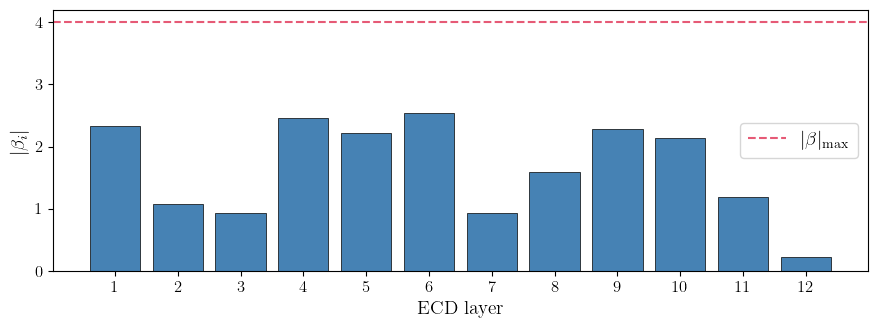

In [12]:
p = res_ecd.params
thetas = jnp.asarray(p["thetas"])
phis = jnp.asarray(p["phis"])
betas = jnp.asarray(p["betas"])
disp_mags = jnp.asarray(p["disp_magnitudes"])

print("thetas :", jnp.round(thetas, 3))
print("phis   :", jnp.round(phis, 3))
print("betas  :", [f"{b:.3f}" for b in betas])

fig, ax = plt.subplots(figsize=(9, 3.5))
layers = jnp.arange(1, disp_mags.size + 1)
ax.bar(layers, disp_mags, color="steelblue", edgecolor="black", linewidth=0.5)
ax.axhline(bounds.max_disp, color="crimson", linestyle="--", alpha=0.7,
           label=r"$|\beta|_{\max}$")
ax.set_xlabel("ECD layer")
ax.set_ylabel(r"$|\beta_i|$")
ax.set_xticks(layers)
ax.legend()
fig.tight_layout()
plt.show()

## Warm starts

Passing `params0` replaces the random initialization. A `(n_params,)` vector skips the multi-start entirely and optimizes that single point — the natural way to push an existing solution further with a longer, gentler run. A `(n_seeds, n_params)` array replaces the whole batch, which is useful for seeding a deeper circuit from a shallower solution or for sweeping a target while carrying parameters forward.

Note that `n_seeds` is ignored for a 1D `params0`; the reported seed count becomes 1.

In [13]:
res_warm = optimize_gate_sequence(
    "ecd",
    12,
    vac,
    gkp_0,
    disp_method="quadrature",
    loss_type="log_infidelity",
    bounds=bounds,
    optimizer=OptimizerConfig(n_adam_iters=1500, peak_lr=0.005, polish_maxiter=2000),
    params0=jnp.asarray(res_ecd.flat_params),
)

print(f"\nbefore: 1 - F = {1 - res_ecd.fidelity:.3e}")
print(f"after : 1 - F = {1 - res_warm.fidelity:.3e}")

gate set : ecd   depth : 12   n_fock : 80
params   : 50   state pairs : 1   reduction : mean
loss     : log_infidelity   disp : quadrature   seeds : 1
--------------------------------------------------------------
Adam (1500 iters x 1 seeds) in 10.9s
  seed fidelities: best 0.997651, median 0.997651, worst 0.997651
  best seed: 0
L-BFGS-B polish: 381 iters in 3.3s  ->  F = 0.997652
--------------------------------------------------------------
Final fidelity : 0.997652   (infidelity 2.348e-03)
Leakage        : 3.105e-10  (top 8 Fock levels)
Peak |disp|    : 2.503
Total time     : 14.5s

before: 1 - F = 3.193e-03
after : 1 - F = 2.348e-03


## Optimizing a gate, not just a state

Passing `K > 1` state pairs optimizes *one* parameter set for all of them simultaneously, which is how you target a logical gate rather than a single preparation. For the logical $X_L$ we need $\ket{0_L} \to \ket{1_L}$ and $\ket{1_L} \to \ket{0_L}$ under the same circuit.

`batch_reduction` decides how the pairs combine, and the choice is not cosmetic:

- `"mean"` averages the per-pair fidelities. Each pair may be satisfied with its own independent phase, so a "perfect" score does not imply a coherent gate.
- `"coherent"` averages the *overlaps* before squaring, $F = |\overline{\braket{\psi_t | U | \psi_i}}|^2$. This fixes the relative phase between logical basis states and leaves only one global phase free — the right objective for a gate on a subspace.

Since the inputs here are orthonormal and span the logical space, constraining these two pairs coherently determines the action on the whole subspace up to that global phase; adding the $\ket{\pm_L}$ pairs would be redundant. Note also that `"coherent"` requires `qubit_target="ground"` (the default): a traced-out qubit has no well-defined overlap phase, and the module raises rather than silently averaging something meaningless.

In [16]:
res_x = optimize_gate_sequence(
    "ecd",
    4,
    [gkp_0, gkp_1],  # inputs
    [gkp_1, gkp_0],  # targets: logical X_L
    disp_method="quadrature",
    loss_type="log_infidelity",
    batch_reduction="coherent",
    bounds=bounds,
    optimizer=OptimizerConfig(n_seeds=32, n_adam_iters=2000, seed=3),
)

per_pair = jnp.asarray(res_x.params["per_pair_fidelity"])
print()
print(f"coherent F : {res_x.fidelity:.6f}")
print("per-pair F :", jnp.round(per_pair, 6))

gate set : ecd   depth : 4   n_fock : 80
params   : 18   state pairs : 2   reduction : coherent
loss     : log_infidelity   disp : quadrature   seeds : 32
--------------------------------------------------------------
Adam (2000 iters x 32 seeds) in 106.9s
  seed fidelities: best 0.998870, median 0.944956, worst 0.807582
  best seed: 10
L-BFGS-B polish: 2 iters in 0.5s  ->  F = 0.998870
--------------------------------------------------------------
Final fidelity : 0.998870   (infidelity 1.130e-03)
Leakage        : 2.843e-07  (top 8 Fock levels)
Peak |disp|    : 2.550
Total time     : 107.9s

coherent F : 0.998870
per-pair F : [0.999525 0.998222]


The per-pair fidelities are reported alongside the coherent figure precisely so you can spot the failure mode where both pairs land on their targets individually but with a relative phase error — high per-pair values with a noticeably lower coherent $F$.

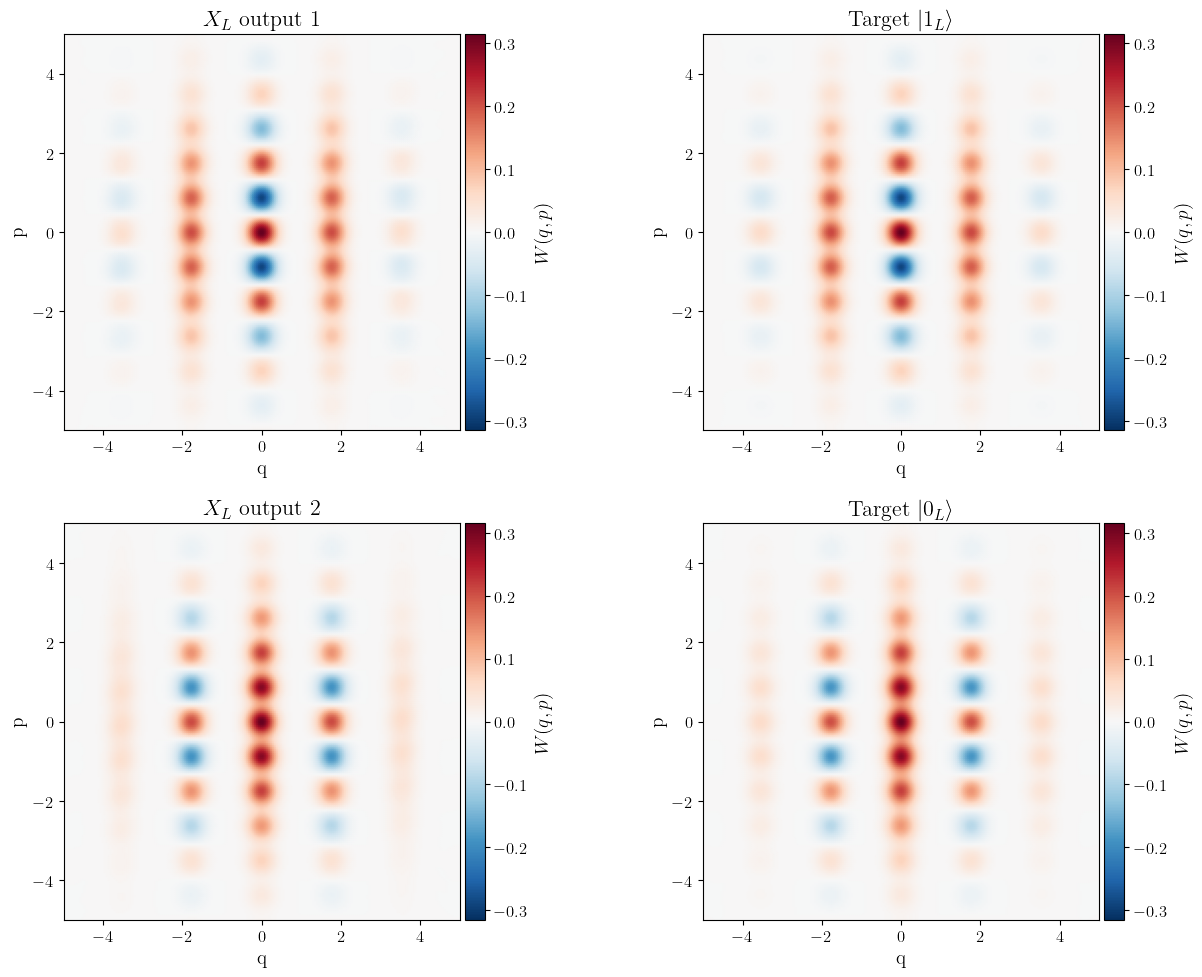

In [17]:
finals = res_x.final_qarray()  # list of Qarrays, one per pair

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, (achieved, target, name) in enumerate(
    zip(finals, [gkp_1, gkp_0], [r"1_L", r"0_L"])
):
    plot_wigner(achieved, x_bound=5, y_bound=5, ax=axes[row][0],
                title=rf"$X_L$ output {row + 1}")
    plot_wigner(target, x_bound=5, y_bound=5, ax=axes[row][1],
                title=rf"Target $\ket{{{name}}}$")
fig.tight_layout()
plt.show()

## Checklist

Things worth confirming before believing a number out of this module:

1. **x64 is enabled**, before any array is created. Otherwise fidelities above $\sim 1 - 10^{-6}$ are noise.
2. **The displacement operator is unitary.** Both supplied methods are; the closed-form Fock matrix elements are not, and the module refuses to offer them for that reason.
3. **The truncation holds mid-circuit, not just at the endpoints.** Check `leakage`, check the photon-number tail, and remember that `n_leak` levels are penalized after every displacement.
4. **The seed spread is not suspicious.** Wide spread means add seeds; narrow spread at high infidelity means add depth. The best single seed of sixteen is a very different claim from a converged optimum.
5. **`loss_type="log_infidelity"`** once you are past $F \approx 0.99$.
6. **`batch_reduction="coherent"`** for gates; `"mean"` for independent state preparations.
7. **Never duck-type a `Qarray`.** `hasattr(state, ...)` and `jnp.asarray(state)` both raise `NotImplementedError` on one rather than falling through. Cross the boundary with `to_qarray` / `to_ket`, which dispatch on `isinstance` first.
8. **Fidelities here are ansatz-limited only.** The gates are ideal unitaries. Kerr, finite gate duration, and ancilla decoherence all live in `grape.py`'s world, not this one, so treat these numbers as the ceiling a real device works toward.

For anything the top-level entry point does not expose, `build_sequence(gate_set, n_gates, n_fock, **kwargs)` returns the underlying `GateSequence` directly — its `propagate`, `history`, `overlaps`, `fidelity`, `init`, and `describe` closures are the pieces `optimize_gate_sequence` is assembled from, and they are all jittable and differentiable on their own.